In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from keras.callbacks import EarlyStopping

In [27]:
df = pd.read_csv('Datasets/HousingData.csv')
df.dropna(inplace=True)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7


In [28]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 394 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     394 non-null    float64
 1   ZN       394 non-null    float64
 2   INDUS    394 non-null    float64
 3   CHAS     394 non-null    float64
 4   NOX      394 non-null    float64
 5   RM       394 non-null    float64
 6   AGE      394 non-null    float64
 7   DIS      394 non-null    float64
 8   RAD      394 non-null    int64  
 9   TAX      394 non-null    int64  
 10  PTRATIO  394 non-null    float64
 11  B        394 non-null    float64
 12  LSTAT    394 non-null    float64
 13  MEDV     394 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 46.2 KB


(394, 14)

In [29]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [81]:
# Build the model
model = Sequential()
model.add(Dense(64, input_dim=X.shape[1], activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))  # Output layer (linear)

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# EarlyStopping callback: stop if val_loss doesn't improve by at least 10 over 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    min_delta=3,         # Minimum change to qualify as improvement
    patience=5,          # Number of epochs to wait
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100


/home/ritesh/Desktop/Projects/PyPro/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 553.8317 - mae: 21.4904 - val_loss: 493.6317 - val_mae: 20.8250
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 529.5245 - mae: 21.0826 - val_loss: 471.5880 - val_mae: 20.2923
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 477.4219 - mae: 20.0001 - val_loss: 444.5639 - val_mae: 19.6226
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 464.8431 - mae: 19.5537 - val_loss: 412.7400 - val_mae: 18.8067
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 478.1280 - mae: 19.6786 - val_loss: 375.2706 - val_mae: 17.8049
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 405.0398 - mae: 17.9779 - val_loss: 333.3859 - val_mae: 16.6104
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 340.6496 - mae: 16.1942 - val_loss: 287.8010 - val_mae: 15.2054
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 313.5177 - mae: 15.1326 - val_loss: 239.1178 - val_mae: 13.5870
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━

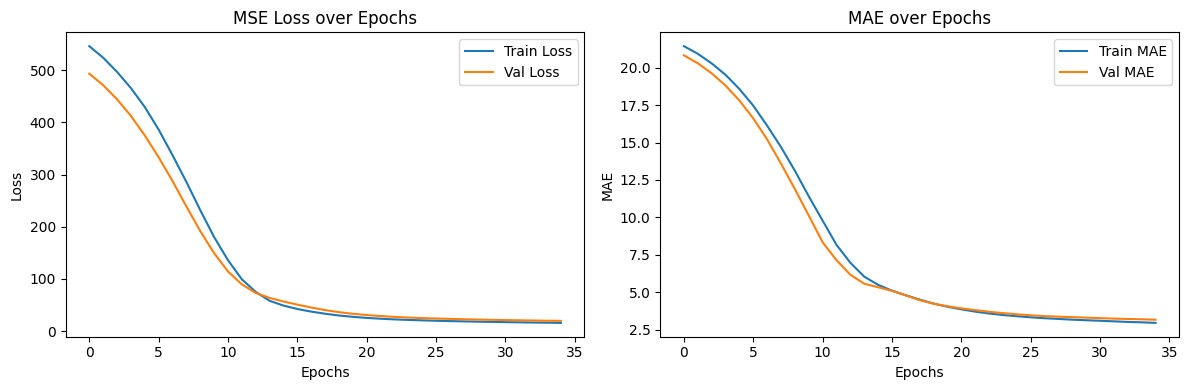

In [82]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MSE Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training MAE and validation MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [73]:
y_pred = model.predict(X_test).flatten()
for idx, (pred, actual) in enumerate(zip(y_pred, y_test)):
    print(f"{idx}: Predicted = {pred:.2f}, Actual = {actual:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
0: Predicted = 20.56, Actual = 25.00
1: Predicted = 23.87, Actual = 18.60
2: Predicted = 16.97, Actual = 21.00
3: Predicted = 30.81, Actual = 23.50
4: Predicted = 12.00, Actual = 17.50
5: Predicted = 35.02, Actual = 33.80
6: Predicted = 23.53, Actual = 19.70
7: Predicted = 33.46, Actual = 24.80
8: Predicted = 29.58, Actual = 32.00
9: Predicted = 14.26, Actual = 14.00
10: Predicted = 18.29, Actual = 21.70
11: Predicted = 43.68, Actual = 50.00
12: Predicted = 25.89, Actual = 16.50
13: Predicted = 19.14, Actual = 20.00
14: Predicted = 10.26, Actual = 20.60
15: Predicted = 27.28, Actual = 24.10
16: Predicted = 15.84, Actual = 19.40
17: Predicted = 19.35, Actual = 17.20
18: Predicted = 16.54, Actual = 50.00
19: Predicted = 11.32, Actual = 11.00
20: Predicted = 14.31, Actual = 18.20
21: Predicted = 14.02, Actual = 16.80
22: Predicted = 15.87, Actual = 12.60
23: Predicted = 31.93, Actual = 24.00
24: Predicted = 23.67, Actual = 22.60
25: Predicted = 14.17,